<a href="https://colab.research.google.com/github/AbhinavDharam/Netflix-Content-Strategy-Viewer-Preference-Analysis/blob/main/Cast_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_netflix_data.csv to cleaned_netflix_data.csv


In [ ]:
df = pd.read_csv('cleaned_netflix_data.csv')

In [ ]:
df['cast_list'] = df['cast'].apply(
    lambda x: [i.strip() for i in x.split(',')] if x != 'Not Available' else []
)
df['genre_list'] = df['listed_in'].apply(lambda x: [i.strip() for i in x.split(',')])

In [ ]:
cast_df = df.explode('cast_list')
cast_df = cast_df[cast_df['cast_list'].notna()]
cast_df = cast_df[cast_df['cast_list'] != '']
cast_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,director_list,genre_list,cast_list
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,[],"[International TV Shows, TV Dramas, TV Sci-Fi ...",João Miguel
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,[],"[International TV Shows, TV Dramas, TV Sci-Fi ...",Bianca Comparato
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,[],"[International TV Shows, TV Dramas, TV Sci-Fi ...",Michel Gomes
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,[],"[International TV Shows, TV Dramas, TV Sci-Fi ...",Rodolfo Valente
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,[],"[International TV Shows, TV Dramas, TV Sci-Fi ...",Vaneza Oliveira


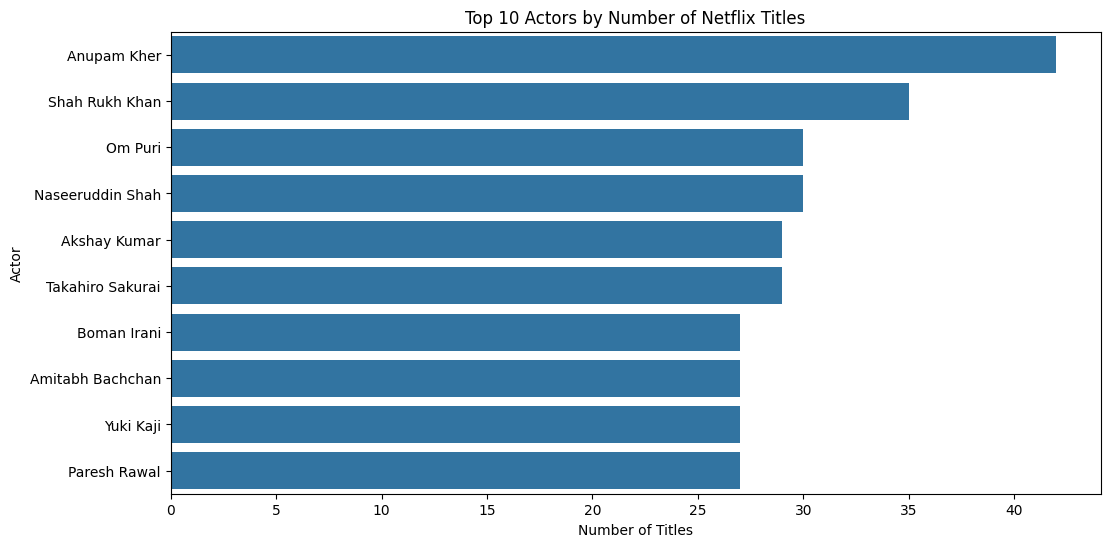

In [ ]:
#Actors with most netflix appearances
top_actors = cast_df['cast_list'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_actors.values, y=top_actors.index)
plt.title("Top 10 Actors by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")
plt.show()


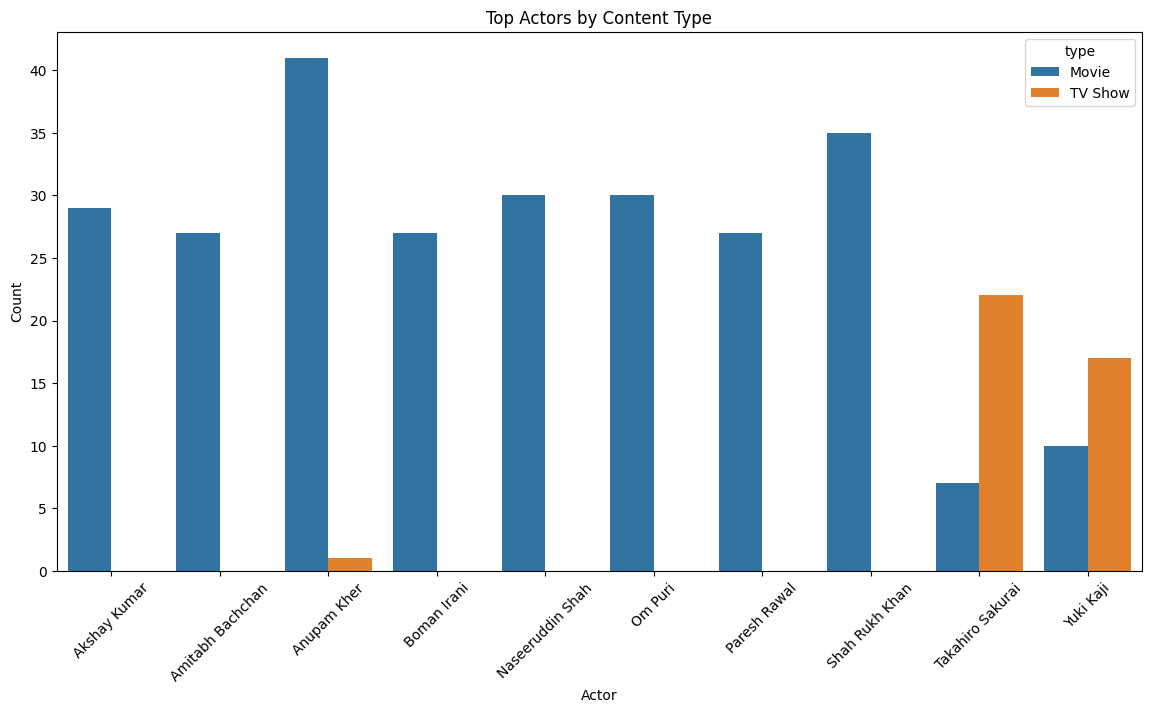

In [ ]:
#Actors by content type
actor_type = cast_df.groupby(['cast_list', 'type']).size().reset_index(name='count')

top_actor_names = cast_df['cast_list'].value_counts().head(10).index
actor_type_top = actor_type[actor_type['cast_list'].isin(top_actor_names)]

plt.figure(figsize=(14,7))
sns.barplot(data=actor_type_top, x='cast_list', y='count', hue='type')
plt.xticks(rotation=45)
plt.title("Top Actors by Content Type")
plt.xlabel("Actor")
plt.ylabel("Count")
plt.show()

In [ ]:
#Actor-Genre
actor_genre_df = df.explode('cast_list').explode('genre_list')
actor_genre_df = actor_genre_df[actor_genre_df['cast_list'] != 'Unknown']

actor_genre_counts = actor_genre_df.groupby(['cast_list', 'genre_list']).size().reset_index(name='count')
actor_genre_counts = actor_genre_counts.sort_values('count', ascending=False)

print(actor_genre_counts.head(15))

              cast_list            genre_list  count
7755        Anupam Kher  International Movies     37
83750    Shah Rukh Khan  International Movies     32
83749    Shah Rukh Khan                Dramas     28
7753        Anupam Kher                Dramas     28
69589           Om Puri  International Movies     27
2330       Akshay Kumar  International Movies     27
66258  Naseeruddin Shah                Dramas     26
47084    Kareena Kapoor  International Movies     25
66260  Naseeruddin Shah  International Movies     25
70573      Paresh Rawal  International Movies     25
12560       Boman Irani  International Movies     24
4856   Amitabh Bachchan  International Movies     22
89552  Takahiro Sakurai          Anime Series     21
2113         Ajay Devgn  International Movies     21
4855   Amitabh Bachchan                Dramas     20
